11_xgboost_cv_final: XGBoost with Cross Validation

项目根目录: C:\Users\LENOVO\Desktop\machinelearning_project
数据目录: C:\Users\LENOVO\Desktop\machinelearning_project\data
模型保存目录: C:\Users\LENOVO\Desktop\machinelearning_project\models\xgb_cv_final

1. 加载数据...
训练集: (700000, 26)
测试集: (300000, 25)

2. 准备数据...
原始特征数: 24

3. 添加工程特征...
添加后特征数: 29

4. 编码类别特征...
编码后特征数: 29
训练集特征数: 29
测试集特征数: 29

5. Dummy Baseline...
Dummy Classifier AUC: 0.5000 (baseline reference)

6. 开始5折交叉验证...

Fold 1/5
训练集: 560000 样本
验证集: 140000 样本
验证集 AUC: 0.725961
最佳迭代次数: 1993
模型已保存: C:\Users\LENOVO\Desktop\machinelearning_project\models\xgb_cv_final\xgb_fold_1.json

Fold 2/5
训练集: 560000 样本
验证集: 140000 样本
验证集 AUC: 0.724282
最佳迭代次数: 1997
模型已保存: C:\Users\LENOVO\Desktop\machinelearning_project\models\xgb_cv_final\xgb_fold_2.json

Fold 3/5
训练集: 560000 样本
验证集: 140000 样本
验证集 AUC: 0.725153
最佳迭代次数: 1999
模型已保存: C:\Users\LENOVO\Desktop\machinelearning_project\models\xgb_cv_final\xgb_fold_3.json

Fold 4/5
训练集: 560000 样本
验证集: 140000 样本
验证

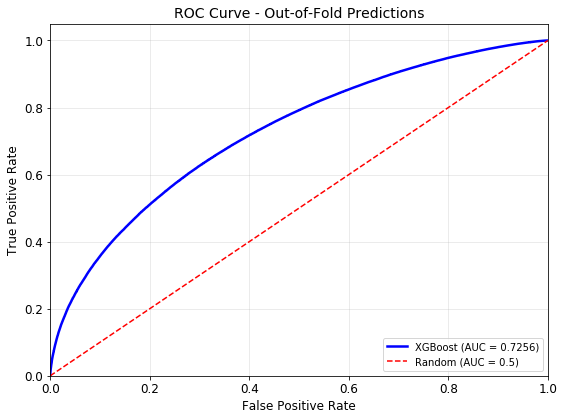

✓ ROC曲线已保存: C:\Users\LENOVO\Desktop\machinelearning_project\figures\roc_curve.png


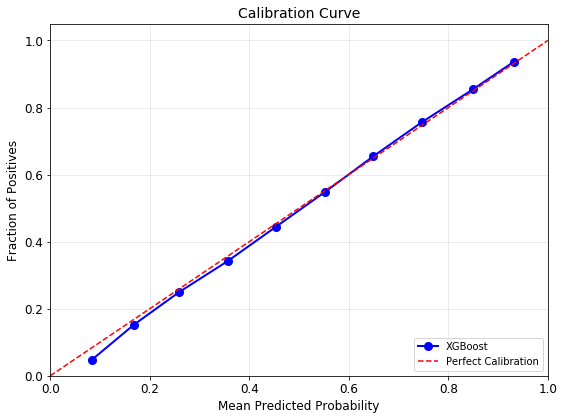

✓ 校准曲线已保存: C:\Users\LENOVO\Desktop\machinelearning_project\figures\calibration_curve.png


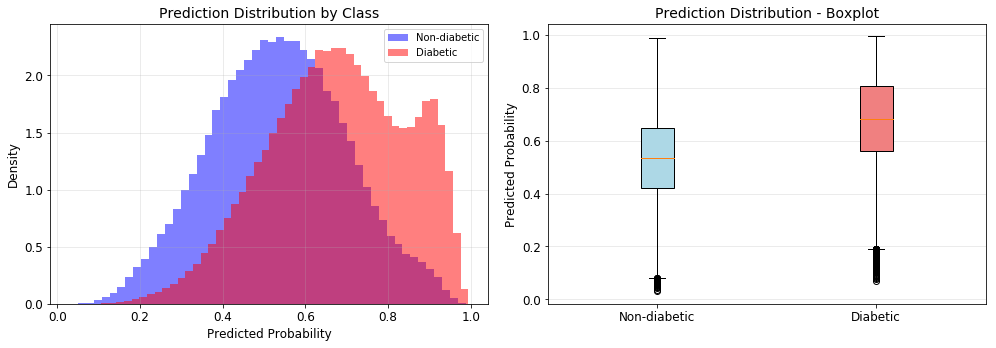

✓ 预测分布图已保存: C:\Users\LENOVO\Desktop\machinelearning_project\figures\prediction_distribution.png


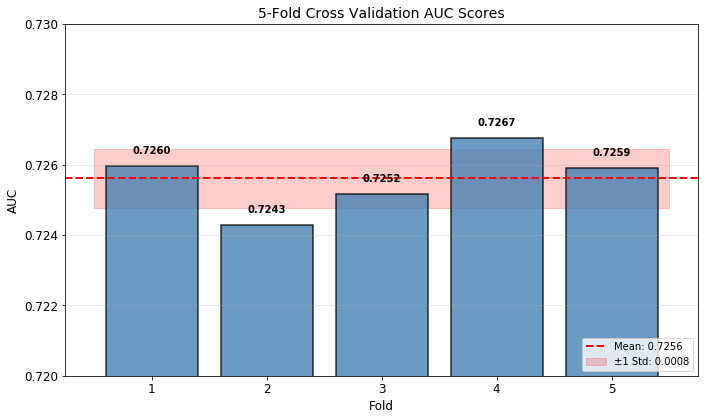

✓ 各折AUC图已保存: C:\Users\LENOVO\Desktop\machinelearning_project\figures\fold_aucs.png

生成特征重要性图...


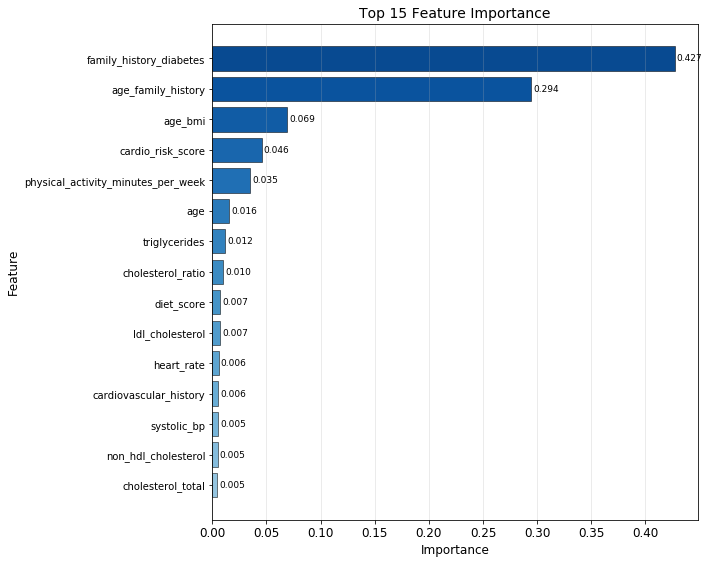

✓ 特征重要性图已保存: C:\Users\LENOVO\Desktop\machinelearning_project\figures\feature_importance.png

生成特征重要性饼图...


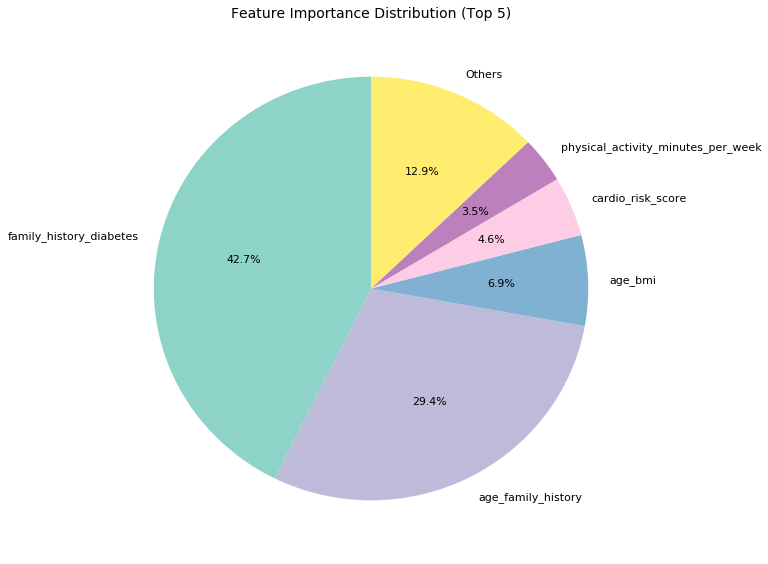

✓ 特征重要性饼图已保存: C:\Users\LENOVO\Desktop\machinelearning_project\figures\feature_importance_pie.png

10. 保存结果...
✓ OOF预测已保存: C:\Users\LENOVO\Desktop\machinelearning_project\logs\11_xgboost_cv_oof_predictions.csv
✓ 特征重要性已保存: C:\Users\LENOVO\Desktop\machinelearning_project\logs\11_xgboost_cv_feature_importance.csv
✓ 提交文件已保存: C:\Users\LENOVO\Desktop\machinelearning_project\submissions\11_xgboost_cv_submission.csv

11. 保存实验总结...
✓ 实验总结已保存: C:\Users\LENOVO\Desktop\machinelearning_project\logs\11_xgboost_cv_summary.json

实验完成！

最终结果:
- Dummy Baseline AUC: 0.5000
- 5折交叉验证平均 AUC: 0.725611 (±0.000835)
- OOF AUC: 0.725604
- 提交文件: C:\Users\LENOVO\Desktop\machinelearning_project\submissions\11_xgboost_cv_submission.csv

Top 5 最重要特征:

  22. family_history_diabetes: 0.4271
  25. age_family_history: 0.2945
  26. age_bmi: 0.0692
  27. cardio_risk_score: 0.0456
  3. physical_activity_minutes_per_week: 0.0352


In [2]:
# 11_xgboost_cv_final.ipynb

import sys
sys.path.append('..')

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

print("="*60)
print("11_xgboost_cv_final: XGBoost with Cross Validation")
print("="*60)

# 路径设置
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT / 'models/xgb_cv_final'
SUBMISSION_DIR = PROJECT_ROOT / 'submissions'
LOG_DIR = PROJECT_ROOT / 'logs'
FIGURE_DIR = PROJECT_ROOT / 'figures'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'diagnosed_diabetes'
N_SPLITS = 5
RANDOM_STATE = 42

print(f"\n项目根目录: {PROJECT_ROOT}")
print(f"数据目录: {DATA_DIR}")
print(f"模型保存目录: {MODEL_DIR}")


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """添加工程特征（保留原始特征）"""
    df = df.copy()
    
    # 交互特征（保留原始age和family_history_diabetes）
    df['age_family_history'] = df['age'] * df['family_history_diabetes']
    df['age_bmi'] = df['age'] * df['bmi']
    
    # 心血管风险评分
    df['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    
    # 胆固醇指标
    df['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    
    return df


def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    """Label encoding for categorical features"""
    df = df.copy()
    categorical_cols = ['gender', 'ethnicity', 'education_level', 
                        'income_level', 'smoking_status', 'employment_status']
    
    for col in categorical_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = df[col].fillna('Unknown')
            df[col] = le.fit_transform(df[col].astype(str))
    
    return df


def build_model(seed: int = RANDOM_STATE) -> XGBClassifier:
    """构建XGBoost模型（使用优化后的参数）"""
    return XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=seed,
        n_jobs=-1,
        early_stopping_rounds=100,
        verbosity=0
    )


def plot_roc_curve(y_true, y_pred, title=None, save_path=None):
    """绘制ROC曲线"""
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_score:.4f}')
    plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title or 'ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_calibration_curve(y_true, y_pred, title=None, save_path=None):
    """绘制校准曲线"""
    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10)
    
    plt.figure(figsize=(6, 5))
    plt.plot(prob_pred, prob_true, 'o-', linewidth=2, label='XGBoost')
    plt.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(title or 'Calibration Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_prediction_distribution(y_true, y_pred, title=None, save_path=None):
    """绘制预测概率分布"""
    plt.figure(figsize=(8, 5))
    plt.hist(y_pred[y_true == 0], bins=50, alpha=0.5, label='Non-diabetic', color='blue')
    plt.hist(y_pred[y_true == 1], bins=50, alpha=0.5, label='Diabetic', color='red')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title(title or 'Prediction Distribution by Class')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def main():
    # 1. 加载数据
    print("\n1. 加载数据...")
    train_df = pd.read_csv(DATA_DIR / 'train.csv')
    test_df = pd.read_csv(DATA_DIR / 'test.csv')
    sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')
    
    print(f"训练集: {train_df.shape}")
    print(f"测试集: {test_df.shape}")
    
    # 获取列名
    id_col = sample_sub.columns[0]
    pred_col = sample_sub.columns[1]
    
    # 2. 准备数据
    print("\n2. 准备数据...")
    X = train_df.drop(columns=[id_col, TARGET])
    y = train_df[TARGET].astype(int)
    X_test = test_df.drop(columns=[id_col])
    
    print(f"原始特征数: {X.shape[1]}")
    
    # 3. 添加工程特征
    print("\n3. 添加工程特征...")
    X = add_engineered_features(X)
    X_test = add_engineered_features(X_test)
    print(f"添加后特征数: {X.shape[1]}")
    
    # 4. 编码类别特征
    print("\n4. 编码类别特征...")
    X = encode_categorical(X)
    X_test = encode_categorical(X_test)
    print(f"编码后特征数: {X.shape[1]}")
    
    # 确保测试集和训练集列一致
    missing_cols = set(X.columns) - set(X_test.columns)
    for col in missing_cols:
        X_test[col] = 0
    X_test = X_test[X.columns]
    
    print(f"训练集特征数: {X.shape[1]}")
    print(f"测试集特征数: {X_test.shape[1]}")
    
    # 5. Dummy Baseline
    print("\n5. Dummy Baseline...")
    X_sample, X_val_sample, y_sample, y_val_sample = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_sample, y_sample)
    dummy_pred = dummy.predict_proba(X_val_sample)[:, 1]
    dummy_auc = roc_auc_score(y_val_sample, dummy_pred)
    print(f"Dummy Classifier AUC: {dummy_auc:.4f} (baseline reference)")
    
    # 6. 5折交叉验证
    print("\n6. 开始5折交叉验证...")
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    
    oof_pred = np.zeros(len(X), dtype=float)
    test_pred = np.zeros(len(X_test), dtype=float)
    fold_scores = []
    best_iterations = []
    feature_importance_sum = np.zeros(X.shape[1])
    
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\n{'='*40}")
        print(f"Fold {fold}/{N_SPLITS}")
        print(f"{'='*40}")
        
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        
        print(f"训练集: {len(X_train)} 样本")
        print(f"验证集: {len(X_valid)} 样本")
        
        # 训练模型
        model = build_model(seed=RANDOM_STATE + fold)
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )
        
        # 验证集预测
        valid_pred = model.predict_proba(X_valid)[:, 1]
        fold_auc = roc_auc_score(y_valid, valid_pred)
        oof_pred[valid_idx] = valid_pred
        fold_scores.append(fold_auc)
        
        # 获取最佳迭代次数
        best_iter = model.best_iteration if hasattr(model, 'best_iteration') else None
        best_iterations.append(best_iter)
        
        print(f"验证集 AUC: {fold_auc:.6f}")
        if best_iter:
            print(f"最佳迭代次数: {best_iter}")
        
        # 累积特征重要性
        feature_importance_sum += model.feature_importances_
        
        # 测试集预测（累加）
        test_pred += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
        # 保存模型
        model.save_model(MODEL_DIR / f'xgb_fold_{fold}.json')
        print(f"模型已保存: {MODEL_DIR / f'xgb_fold_{fold}.json'}")
    
    # 7. 计算最终结果
    print("\n" + "="*60)
    print("交叉验证结果汇总")
    print("="*60)
    
    oof_auc = roc_auc_score(y, oof_pred)
    mean_fold_auc = np.mean(fold_scores)
    std_fold_auc = np.std(fold_scores)
    
    print(f"\n各折 AUC: {[round(s, 6) for s in fold_scores]}")
    print(f"平均 AUC: {mean_fold_auc:.6f}")
    print(f"标准差: {std_fold_auc:.6f}")
    print(f"OOF AUC: {oof_auc:.6f}")
    
    # 8. 特征重要性
    print("\n8. 特征重要性分析...")
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': feature_importance_sum / N_SPLITS
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 最重要特征:")
    print(feature_importance.head(10).to_string(index=False))
    
    # 替换绘图部分（从第9部分开始）

    # 9. 可视化分析（优化版）
    print("\n9. 生成可视化分析...")

    # 设置全局字体大小
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['legend.fontsize'] = 10

    # 图1：ROC曲线（更清晰）
    fig, ax = plt.subplots(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(y, oof_pred)
    auc_score = roc_auc_score(y, oof_pred)

    ax.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'XGBoost (AUC = {auc_score:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curve - Out-of-Fold Predictions', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ ROC曲线已保存: {FIGURE_DIR / 'roc_curve.png'}")

    # 图2：校准曲线（优化版）
    fig, ax = plt.subplots(figsize=(8, 6))
    prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=10, strategy='uniform')

    ax.plot(prob_pred, prob_true, 'o-', color='blue', linewidth=2, markersize=8, label='XGBoost')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect Calibration')
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Fraction of Positives', fontsize=12)
    ax.set_title('Calibration Curve', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'calibration_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 校准曲线已保存: {FIGURE_DIR / 'calibration_curve.png'}")

    # 图3：预测概率分布（优化版，分开显示）
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 左侧：密度分布图（更清晰）
    ax1 = axes[0]
    # 用密度图代替直方图，避免重叠
    for label, color, name in [(0, 'blue', 'Non-diabetic'), (1, 'red', 'Diabetic')]:
        mask = y == label
        ax1.hist(oof_pred[mask], bins=50, alpha=0.5, density=True, 
                color=color, label=name, edgecolor='none')
    ax1.set_xlabel('Predicted Probability', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.set_title('Prediction Distribution by Class', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 右侧：分开的箱线图（更清晰显示差异）
    ax2 = axes[1]
    data_to_plot = [oof_pred[y == 0], oof_pred[y == 1]]
    bp = ax2.boxplot(data_to_plot, labels=['Non-diabetic', 'Diabetic'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    ax2.set_ylabel('Predicted Probability', fontsize=12)
    ax2.set_title('Prediction Distribution - Boxplot', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'prediction_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 预测分布图已保存: {FIGURE_DIR / 'prediction_distribution.png'}")

    # 图4：各折AUC柱状图（优化版）
    fig, ax = plt.subplots(figsize=(10, 6))

    # 柱状图
    bars = ax.bar(range(1, N_SPLITS + 1), fold_scores, color='steelblue', 
                edgecolor='black', linewidth=1.5, alpha=0.8)

    # 在柱子上添加数值
    for bar, score in zip(bars, fold_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0003,
                f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # 平均线
    ax.axhline(y=mean_fold_auc, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_fold_auc:.4f}')

    # 标准差区间
    ax.fill_between([0.5, 5.5], [mean_fold_auc - std_fold_auc, mean_fold_auc - std_fold_auc],
                    [mean_fold_auc + std_fold_auc, mean_fold_auc + std_fold_auc],
                    alpha=0.2, color='red', label=f'±1 Std: {std_fold_auc:.4f}')

    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('AUC', fontsize=12)
    ax.set_title('5-Fold Cross Validation AUC Scores', fontsize=14)
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.set_ylim(0.72, 0.73)  # 固定范围，让差异更明显
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'fold_aucs.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 各折AUC图已保存: {FIGURE_DIR / 'fold_aucs.png'}")

    # 图5：特征重要性条形图（优化版）
    print("\n生成特征重要性图...")
    fig, ax = plt.subplots(figsize=(10, 8))

    top_n = 15
    top_features = feature_importance.head(top_n)

    # 水平条形图
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
    bars = ax.barh(range(len(top_features)), top_features['importance'], 
                color=colors[::-1], edgecolor='black', linewidth=0.5)

    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=10)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance', fontsize=14)
    ax.invert_yaxis()

    # 添加数值标签
    for i, (idx, row) in enumerate(top_features.iterrows()):
        ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', 
                va='center', fontsize=9)

    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 特征重要性图已保存: {FIGURE_DIR / 'feature_importance.png'}")

    # 图6：特征重要性饼图（Top 5）
    print("\n生成特征重要性饼图...")
    fig, ax = plt.subplots(figsize=(8, 8))

    top_n_pie = 5
    top_pie = feature_importance.head(top_n_pie)
    others_sum = feature_importance.iloc[top_n_pie:]['importance'].sum()

    pie_data = list(top_pie['importance']) + [others_sum]
    pie_labels = list(top_pie['feature']) + ['Others']

    colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
    wedges, texts, autotexts = ax.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                        colors=colors, startangle=90,
                                        textprops={'fontsize': 11})
    ax.set_title(f'Feature Importance Distribution (Top {top_n_pie})', fontsize=14)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'feature_importance_pie.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 特征重要性饼图已保存: {FIGURE_DIR / 'feature_importance_pie.png'}")
        
    # 10. 保存结果
    print("\n10. 保存结果...")
    
    # 保存OOF预测
    oof_df = pd.DataFrame({
        id_col: train_df[id_col],
        'y_true': y,
        'oof_pred': oof_pred
    })
    oof_df.to_csv(LOG_DIR / '11_xgboost_cv_oof_predictions.csv', index=False)
    print(f"✓ OOF预测已保存: {LOG_DIR / '11_xgboost_cv_oof_predictions.csv'}")
    
    # 保存特征重要性
    feature_importance.to_csv(LOG_DIR / '11_xgboost_cv_feature_importance.csv', index=False)
    print(f"✓ 特征重要性已保存: {LOG_DIR / '11_xgboost_cv_feature_importance.csv'}")
    
    # 保存提交文件
    submission = sample_sub.copy()
    submission[pred_col] = test_pred
    submission.to_csv(SUBMISSION_DIR / '11_xgboost_cv_submission.csv', index=False)
    print(f"✓ 提交文件已保存: {SUBMISSION_DIR / '11_xgboost_cv_submission.csv'}")
    
    # 11. 保存实验总结
    print("\n11. 保存实验总结...")
    
    summary = {
        'experiment': '11_xgboost_cv_final',
        'n_splits': N_SPLITS,
        'random_state': RANDOM_STATE,
        'dummy_baseline_auc': dummy_auc,
        'fold_aucs': fold_scores,
        'mean_fold_auc': float(mean_fold_auc),
        'std_fold_auc': float(std_fold_auc),
        'oof_auc': float(oof_auc),
        'best_iterations': best_iterations,
        'feature_count': X.shape[1],
        'top_features': feature_importance.head(10).to_dict('records'),
        'params': {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'tree_method': 'hist',
            'n_estimators': 2000,
            'learning_rate': 0.03,
            'max_depth': 4,
            'min_child_weight': 5,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 1,
            'reg_alpha': 0.1,
            'reg_lambda': 1,
            'early_stopping_rounds': 100
        }
    }
    
    with open(LOG_DIR / '11_xgboost_cv_summary.json', 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    print(f"✓ 实验总结已保存: {LOG_DIR / '11_xgboost_cv_summary.json'}")
    
    # 12. 打印最终总结
    print("\n" + "="*60)
    print("实验完成！")
    print("="*60)
    print(f"""
最终结果:
- Dummy Baseline AUC: {dummy_auc:.4f}
- 5折交叉验证平均 AUC: {mean_fold_auc:.6f} (±{std_fold_auc:.6f})
- OOF AUC: {oof_auc:.6f}
- 提交文件: {SUBMISSION_DIR / '11_xgboost_cv_submission.csv'}

Top 5 最重要特征:
""")
    for i, row in feature_importance.head(5).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")


if __name__ == "__main__":
    main()